In [31]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

In [35]:
p = Path.cwd()
root = p.parents[2]
print(root)

data_folder = root.parent / 'data' / 'tiingo' / 'commods'
print(data_folder)

for file in Path(data_folder).iterdir():
    print(file)

sys.path.append(str(root / "libs" / "qc"))

/Users/lucius/repos/trading_research
/Users/lucius/repos/data/tiingo/commods
/Users/lucius/repos/data/tiingo/commods/SLV.parquet
/Users/lucius/repos/data/tiingo/commods/.DS_Store
/Users/lucius/repos/data/tiingo/commods/UNL.parquet
/Users/lucius/repos/data/tiingo/commods/UGA.parquet
/Users/lucius/repos/data/tiingo/commods/KRBN.parquet
/Users/lucius/repos/data/tiingo/commods/CANE.parquet
/Users/lucius/repos/data/tiingo/commods/CORN.parquet
/Users/lucius/repos/data/tiingo/commods/SOYB.parquet
/Users/lucius/repos/data/tiingo/commods/commods_panel.parquet
/Users/lucius/repos/data/tiingo/commods/WEAT.parquet
/Users/lucius/repos/data/tiingo/commods/CPER.parquet
/Users/lucius/repos/data/tiingo/commods/USL.parquet
/Users/lucius/repos/data/tiingo/commods/GLD.parquet


In [30]:
from build_panel_commods import build_panel   # or wherever it ends up
build_panel(data_folder)

CANE                                                            \
             open   high      low  close    volume adjOpen adjHigh   adjLow   
date                                                                          
2004-11-18    NaN    NaN      NaN    NaN       NaN     NaN     NaN      NaN   
2004-11-19    NaN    NaN      NaN    NaN       NaN     NaN     NaN      NaN   
2004-11-22    NaN    NaN      NaN    NaN       NaN     NaN     NaN      NaN   
2004-11-23    NaN    NaN      NaN    NaN       NaN     NaN     NaN      NaN   
2004-11-24    NaN    NaN      NaN    NaN       NaN     NaN     NaN      NaN   
...           ...    ...      ...    ...       ...     ...     ...      ...   
2026-08-31  11.26  11.36  11.2600  11.32  260944.0   11.26   11.36  11.2600   
2026-09-01  11.32  11.59  11.3200  11.57  419756.0   11.32   11.59  11.3200   
2026-09-02  11.54  11.72  11.5301  11.66  278652.0   11.54   11.72  11.5301   
2026-09-03  11.31  11.48  11.2350  11.39  371714.0   11.31   11.48  11.2350   
2026-09-04  11.51  11.53  11.4000  11.42  306543.0   11.51   11.53  11.4000   

                               ...   WEAT                                    \
           adjClose adjVolume  ...    low  close     volume adjOpen adjHigh   
date                           ...                                            
2004-11-18      NaN       NaN  ...    NaN    NaN        NaN     NaN     NaN   
2004-11-19      NaN       NaN  ...    NaN    NaN        NaN     NaN     NaN   
2004-11-22      NaN       NaN  ...    NaN    NaN        NaN     NaN     NaN   
2004-11-23      NaN       NaN  ...    NaN    NaN        NaN     NaN     NaN   
2004-11-24      NaN       NaN  ...    NaN    NaN        NaN     NaN     NaN   
...             ...       ...  ...    ...    ...        ...     ...     ...   
2026-08-31    11.32  260944.0  ...  27.19  27.81  2105548.0   27.28  27.816   
2026-09-01    11.57  419756.0  ...  27.80  28.00   714352.0   27.80  28.190   
2026-09-02    11.66  278652.0  ...  27.73  27.86   557956.0   27.76  28.410   
2026-09-03    11.39  371714.0  ...  26.44  27.12   930191.0   26.81  27.240   
2026-09-04    11.42  306543.0  ...  26.46  26.49   762064.0   26.91  26.980   

                                                           
           adjLow adjClose  adjVolume divCash splitFactor  
date                                                       
2004-11-18    NaN      NaN        NaN     NaN         NaN  
2004-11-19    NaN      NaN        NaN     NaN         NaN  
2004-11-22    NaN      NaN        NaN     NaN         NaN  
2004-11-23    NaN      NaN        NaN     NaN         NaN  
2004-11-24    NaN      NaN        NaN     NaN         NaN  
...           ...      ...        ...     ...         ...  
2026-08-31  27.19    27.81  2105548.0     0.0         1.0  
2026-09-01  27.80    28.00   714352.0     0.0         1.0  
2026-09-02  27.73    27.86   557956.0     0.0         1.0  
2026-09-03  26.44    27.12   930191.0     0.0         1.0  
2026-09-04  26.46    26.49   762064.0     0.0         1.0  

[5483 rows x 132 columns]

In [24]:
UNIVERSE = [
    "GLD",    # gold, physical
    "SLV",    # silver, physical
    "CPER",   # copper
    "USL",    # WTI, 12-month strip
    "UGA",    # gasoline
    "UNL",    # natural gas, 12-month strip
    "CORN",
    "WEAT",
    "SOYB",
    "CANE",   # sugar
    "KRBN",   # carbon allowances
]

In [ ]:
import pandas as pd
from panel_quality import diagnose, clean, returns

panel = pd.read_parquet(f"{data_folder}/commods_panel.parquet")
panel.columns.names = ["ticker", "field"]
panel.index.name = "date"

px  = panel.xs("adjClose",  axis=1, level="field")
vol = panel.xs("adjVolume", axis=1, level="field")

print(diagnose(px, vol))        # look before cleaning

filled, mask = clean(px)
rets = returns(filled, mask)

           start         end   obs interior_nan zero_ret zero_ret_pct  \
CANE  2011-09-19  2026-09-04  3763            0      223          5.9   
CORN  2010-06-09  2026-09-04  4086            0       75          1.8   
CPER  2011-11-15  2026-09-04  3722            0      352          9.5   
GLD   2004-11-18  2026-09-04  5483            0       20          0.4   
KRBN  2020-07-30  2026-09-04  1533            0        8          0.5   
SLV   2006-04-28  2026-09-04  5121            0       78          1.5   
SOYB  2011-09-19  2026-09-04  3763            0       85          2.3   
UGA   2008-02-28  2026-09-04  4660            0       18          0.4   
UNL   2010-01-04  2026-09-04  4194            0       85          2.0   
USL   2007-12-06  2026-09-04  4716            0       45          1.0   
WEAT  2011-09-19  2026-09-04  3763            0      140          3.7   

     max_stale_run big_moves nonpositive zero_vol  
CANE             6         0           0      114  
CORN             2 

In [41]:
px

ticker,CANE,CORN,CPER,GLD,KRBN,SLV,SOYB,UGA,UNL,USL,WEAT
date,,,,,,,,,,,
2004-11-18,NaN,NaN,NaN,44.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-19,NaN,NaN,NaN,44.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-22,NaN,NaN,NaN,44.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-23,NaN,NaN,NaN,44.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-24,NaN,NaN,NaN,45.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-31,11.32,20.06,40.00,408.42,34.8000,60.13,27.24,129.21,5.8600,52.3875,27.81
2026-09-01,11.57,20.29,39.07,396.75,34.7400,57.92,27.78,131.70,5.9300,53.5515,28.00
2026-09-02,11.66,20.22,39.53,402.78,35.0900,59.07,27.62,128.91,5.9541,53.4100,27.86


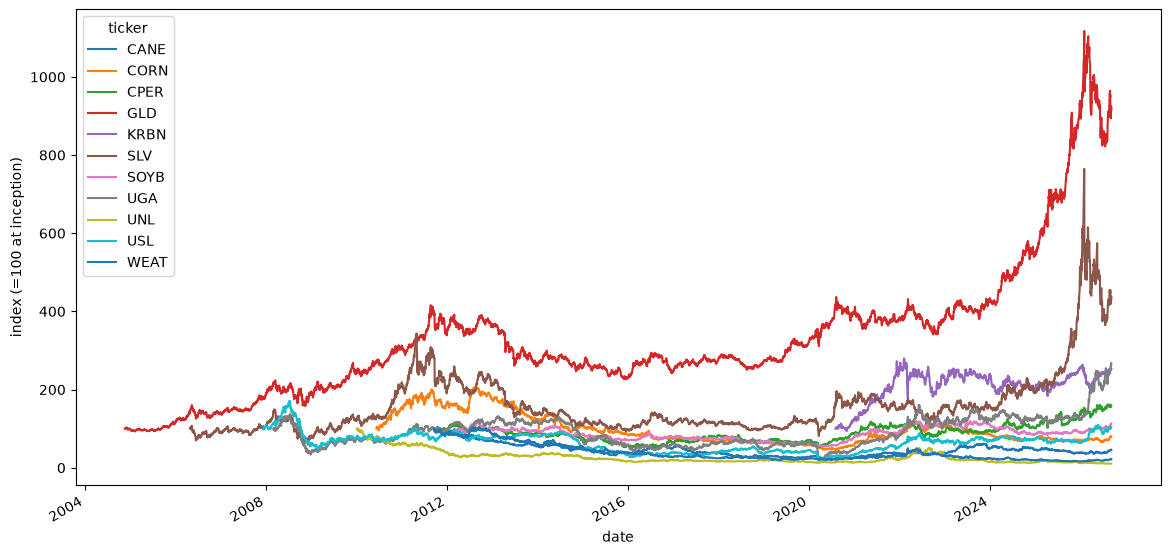

In [46]:
import matplotlib.pyplot as plt

norm = px / px.apply(lambda s: s.loc[s.first_valid_index()]) * 100

norm.plot(figsize=(14, 7), logy=False)
plt.ylabel("index (=100 at inception)")
plt.show()